# Biodiversity response variables — unified database (Parcelas-CL + Living Trees Chile)

Unit of analysis: **one vegetation plot** (`PlotObservationID`), unified pool —
Parcelas-CL (1,082-3,102 depending on facet, 30-38°S) + Living Trees Chile
(tree-level forest inventory, 500/250 m² fixed plots, 2011-2020, full country).
Built by `scripts/50_build_living_trees.py` + `scripts/51_build_unified_dataset.py`
(`plots_unified.parquet`, `occurrences_unified.parquet`), facets by `scripts/52-57`.

Two abundance regimes, used for different things below — never mixed silently:

- **Relativized proportions** (row-relativized within each plot,
  `decostand`/`hill_taxa_parti(rel_then_pool=TRUE)`) — combines Parcelas-CL's 3
  incommensurable currencies (cover %, counts, basal area) with Living Trees' basal
  area. This is what every full-pool facet (`hill_q0_unified`, `lcbd_*_unified`,
  `pd_faith_unified`, the partition/rarefaction curves) uses — it covers (almost)
  every plot, and it is the modelling target set.
- **True individual counts** — only `Abundance_parameter=="Abundance"` in
  Parcelas-CL (479 plots; Cover/Basal_area strata have no recoverable per-individual
  data anywhere in `data/Parcelas_CL_RAW/`, audited this session) + Living Trees via
  tree-row counting (2,020 plots, `scripts/50`'s `tree-level` sheet, one row per
  tree — never used as a count before this session, only summed into basal area).
  Combined by `scripts/61_build_unified_counts.py` → `occurrences_unified_counts.parquet`,
  **2,499 plots**. This is what the Pérez-Giraldo-style facets below need
  (coverage-standardized alpha, Sørensen-quantitative LCBD) and what the redone Hill
  curves use — real counts, not proportions, closer to what a coverage-based
  estimator is designed for.

Coverage-standardized methods (`iNEXT.3D`) hard-require ≥5 observed species per plot
— a structural limit of Chao1-type estimators, not a gate we chose — so the
true-count facets never reach full-pool N. §9 states plainly which facet set to
actually use for modelling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DERIVED = Path('../data/derived')
BLUE, ORANGE, GREEN, RED, PURPLE = '#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2'

unified_plots = pd.read_parquet(DERIVED / 'plots_unified.parquet')
unified_resp = pd.read_parquet(DERIVED / 'unified_diversity_responses.parquet')
phylo = pd.read_parquet(DERIVED / 'unified_phylo_responses.parquet')
dark = pd.read_parquet(DERIVED / 'unified_dark_diversity.parquet')

udf = (unified_resp.merge(unified_plots, on='PlotObservationID', how='left')
                    .merge(phylo, on='PlotObservationID', how='left')
                    .merge(dark, on='PlotObservationID', how='left'))
print('unified plots:', unified_plots.shape)
print('merged        :', udf.shape)
print(unified_plots['source'].value_counts())

unified plots: (3102, 27)
merged        : (3102, 51)
living_trees    2020
parcelas_cl     1082
Name: source, dtype: int64


## 1. Coverage — where the unified pool sits

Living Trees extends Parcelas-CL's central-Chile band (30-38°S) to the full length of
the country. Two real data-quality catches from building it, not silently absorbed:
plot identity is the **coordinate**, not `um`/`region+um` (2 coordinate pairs each
carried two distinct `um` labels for the same physical site); reading the source
Excel without `keep_default_na=False` silently turns species code `"NA"`
(*Nothofagus alpina*) into a missing value, same trap `io_parcelas.py` already avoids
for Parcelas-CL.

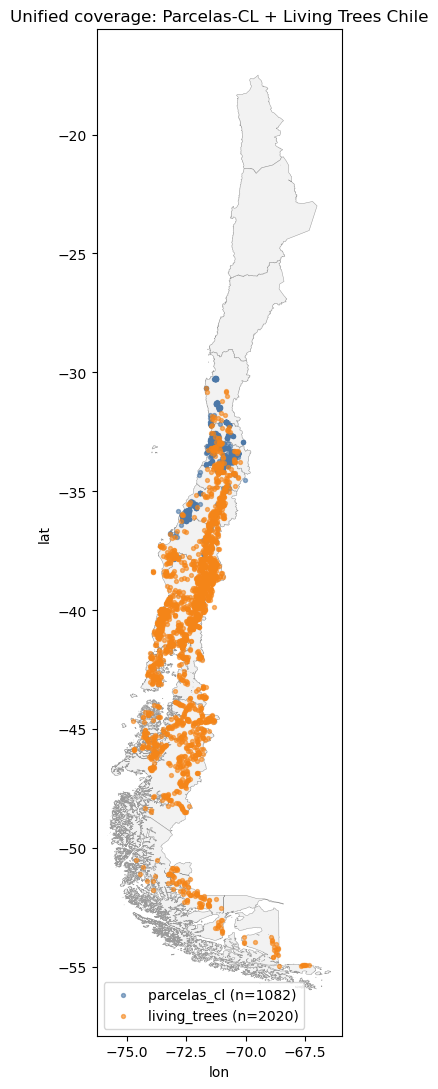

In [2]:
import geopandas as gpd

chile_full = gpd.read_file('../shapefiles/regiones_chile.shp').to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(6, 11))
chile_full.plot(ax=ax, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = unified_plots[unified_plots['source'] == src]
    ax.scatter(sub['lon'], sub['lat'], s=8, alpha=0.6, color=color,
              label=f'{src} (n={len(sub)})')
ax.set(title='Unified coverage: Parcelas-CL + Living Trees Chile',
      xlabel='lon', ylabel='lat', aspect='equal')
ax.legend(loc='lower left')
fig.tight_layout()

## 2. Cross-validation scheme — `kfold5_block20_unified`

`scripts/53_unified_block20_folds.py` — 20×20 km spatial blocks over a Chile-centred
Lambert Azimuthal Equal-Area projection (`X_m`/`Y_m`), not Parcelas-CL's own UTM19S —
raw UTM19S distorts badly far from its central meridian, which matters now that the
footprint reaches Magallanes (~55°S). This is the project's sole primary CV scheme
(`docs/11_next_steps.md`, decision #1) — `kfold5_owner`/`kfold5_random` stay
diagnostic only.

scheme: kfold5_block20_unified
plots with a fold assignment: 3102 of 3102


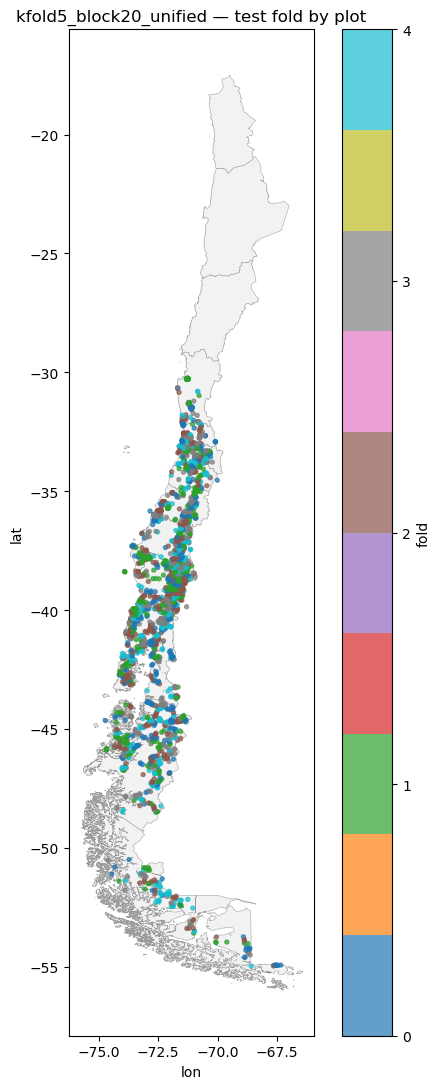

In [3]:
cv_block = pd.read_parquet(DERIVED / 'cv_folds_unified_block20.parquet')
block_test = cv_block[cv_block['split'] == 'test'][['PlotObservationID', 'fold']]
m = unified_plots.merge(block_test, on='PlotObservationID', how='left')
print('scheme:', cv_block['scheme'].iloc[0])
print('plots with a fold assignment:', m['fold'].notna().sum(), 'of', len(m))

fig, ax = plt.subplots(figsize=(6, 11))
chile_full.plot(ax=ax, facecolor='#F2F2F2', edgecolor='#9A9A9A', linewidth=0.35)
sc = ax.scatter(m['lon'], m['lat'], c=m['fold'], cmap='tab10', s=8, alpha=0.7)
ax.set(title='kfold5_block20_unified — test fold by plot',
      xlabel='lon', ylabel='lat', aspect='equal')
fig.colorbar(sc, ax=ax, label='fold', ticks=range(5))
fig.tight_layout()

## 3. Taxonomic diversity and beta (LCBD / composition) — full pool

`scripts/52_unified_diversity_facets.R` (`hillR`/`adespatial::beta.div`/`ape::pcoa`,
Cailliez correction), on relativized proportions:

- **`hill_q0_unified`** — richness, all 3,102 plots. Sanity check already run in the
  R script: `cor(hill_q0_unified, richness) = 1.0000`.
- **`lcbd_pa_unified`** — presence/absence (Jaccard), 3,094 plots (8 Living Trees
  plots excluded: every tree missing `D`, zero basal area, an empty community row
  breaks the PCoA eigendecomposition).
- **`lcbd_freq_unified`** — row-relativized abundance (`decostand(method="total")` +
  Hellinger/Bray), 3,040 plots with *real* measured abundance (cover, counts, or
  basal area) — excludes only the `presence` stratum (`Value` fixed at 1 for every
  species, which would relativize to a flat 1/richness artifact, not a measured
  frequency).

PCoA axis **sign is arbitrary** per run — a strong negative correlation between
`pcoa1_pa_unified` and `pcoa1_freq_unified` is a sign flip, not disagreement.
`lcbd_freq`'s 2 axes explain only 7.0% of variance (below the 20% alert threshold) —
flagged, not hidden, high-dimensional turnover at this richness level.

plots with both pcoa1_pa_unified and pcoa1_freq_unified: 3040
corr(pcoa1_pa_unified, pcoa1_freq_unified) = 0.907 (sign is arbitrary per PCoA run)


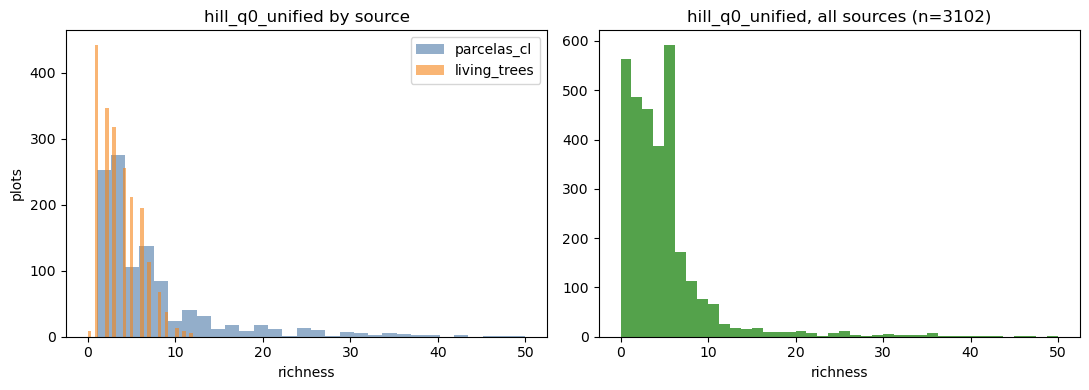

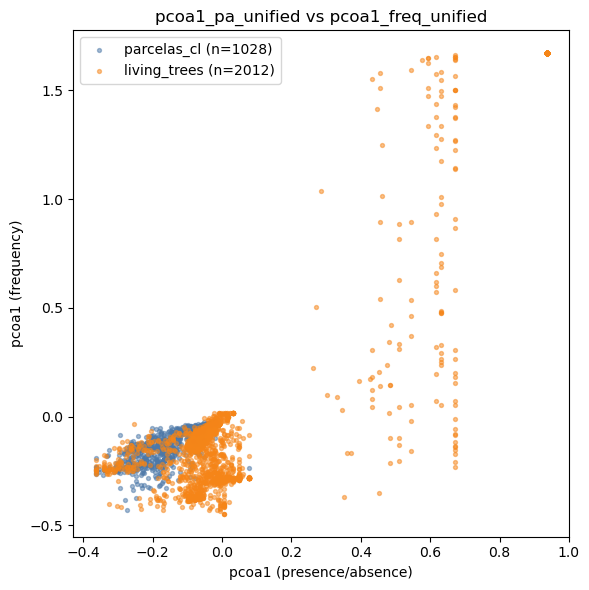

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = udf[udf['source'] == src]
    ax[0].hist(sub['hill_q0_unified'], bins=30, alpha=0.6, color=color, label=src)
ax[0].set(title='hill_q0_unified by source', xlabel='richness', ylabel='plots')
ax[0].legend()
ax[1].hist(udf['hill_q0_unified'], bins=40, color=GREEN)
ax[1].set(title='hill_q0_unified, all sources (n=%d)' % len(udf), xlabel='richness')
fig.tight_layout()

both = udf.dropna(subset=['pcoa1_pa_unified', 'pcoa1_freq_unified'])
print(f"plots with both pcoa1_pa_unified and pcoa1_freq_unified: {len(both)}")
print(f"corr(pcoa1_pa_unified, pcoa1_freq_unified) = "
      f"{both['pcoa1_pa_unified'].corr(both['pcoa1_freq_unified']):.3f} "
      "(sign is arbitrary per PCoA run)")

fig, ax = plt.subplots(figsize=(6, 6))
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = both[both['source'] == src]
    ax.scatter(sub['pcoa1_pa_unified'], sub['pcoa1_freq_unified'], s=8, alpha=0.5,
              color=color, label=f'{src} (n={len(sub)})')
ax.set(title='pcoa1_pa_unified vs pcoa1_freq_unified', xlabel='pcoa1 (presence/absence)',
      ylabel='pcoa1 (frequency)')
ax.legend()
fig.tight_layout()

### 3a. LCBD — true counts, Sørensen-quantitative (Pérez-Giraldo et al. 2025)

A co-author reviewing the methodology asked for LCBD with the exact coefficient
Pérez-Giraldo et al. 2025 (Ecography) use: `adespatial::beta.div.comp(coef="S",
quant=TRUE)` → `LCBD.comp(sqrt.D=TRUE)` (`scripts/62_lcbd_sorensen_pg.R`), on the
true-count matrix (2,499 plots, §intro). Same family of function as §3's
`beta.div` — a different dissimilarity coefficient, not a different method.

              n_plots  mean  median  min  max  n_ge5  pct_ge5
source                                                       
living_trees     2020  3.61     3.0    1   12    651    32.23
parcelas_cl       479  7.63     5.0    1   47    244    50.94


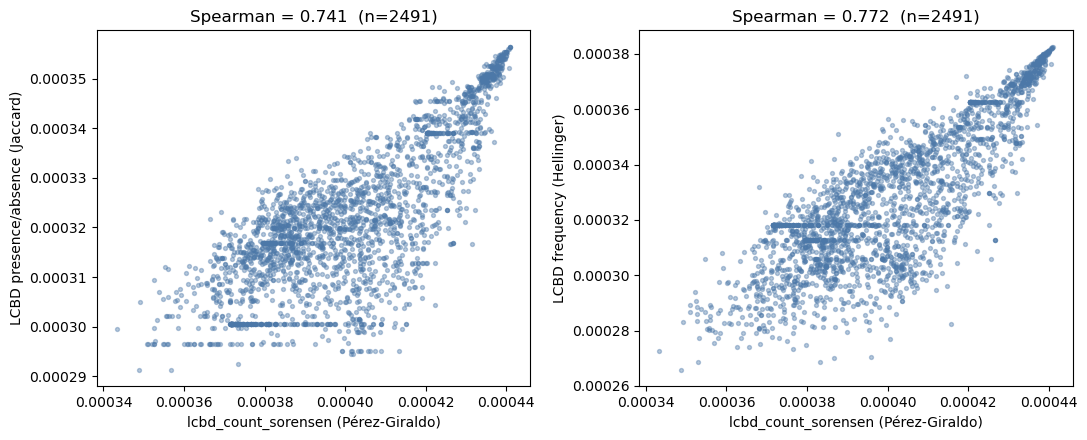

In [5]:
counts = pd.read_parquet(DERIVED / 'occurrences_unified_counts.parquet')
counts['source'] = counts['PlotObservationID'].str.startswith('PCL_').map(
    {True: 'parcelas_cl', False: 'living_trees'})
rich_counts = (counts.groupby(['PlotObservationID', 'source'])['species']
               .nunique().rename('richness').reset_index())
summary = rich_counts.groupby('source')['richness'].agg(
    n_plots='count', mean='mean', median='median', min='min', max='max')
summary['n_ge5'] = rich_counts.groupby('source')['richness'].apply(lambda s: (s >= 5).sum())
summary['pct_ge5'] = 100 * summary['n_ge5'] / summary['n_plots']
print(summary.round(2))

lcbd_pg = pd.read_parquet(DERIVED / 'lcbd_count_sorensen.parquet')
cmp_lcbd = lcbd_pg.merge(udf[['PlotObservationID', 'lcbd_pa_unified', 'lcbd_freq_unified']],
                          on='PlotObservationID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, label in zip(axes, ['lcbd_pa_unified', 'lcbd_freq_unified'],
                          ['LCBD presence/absence (Jaccard)', 'LCBD frequency (Hellinger)']):
    d = cmp_lcbd.dropna(subset=[col])
    rho = d['lcbd_count_sorensen'].corr(d[col], method='spearman')
    ax.scatter(d['lcbd_count_sorensen'], d[col], s=8, alpha=0.4, color=BLUE)
    ax.set(xlabel='lcbd_count_sorensen (Pérez-Giraldo)', ylabel=label,
          title=f'Spearman = {rho:.3f}  (n={len(d)})')
fig.tight_layout()

## 4. Phylogenetic diversity and dark diversity — full pool

`scripts/54_unified_phylo_responses.R` / `scripts/55_unified_dark_diversity.R` —
`V.PhyloMaker2` (`GBOTB.extended.TPL`, scenario S3), `picante::pd/mpd/mntd/ses.*`;
`DarkDiv::DarkDiv` (Hypergeometric, threshold 0.9).

- **Tree**: 610 tips (338 own position, 55%; 272 grafted by genus, 45%).
  `pd_faith_unified` correlates 0.894 with richness (descriptor, not an independent
  signal — expected for a branch-length sum). 563 plots have no `mpd`/`mntd` (<2
  species in the tree, picante's own handling, not filtered by hand).
- **Dark diversity pool**: the *full* Parcelas-CL + Living Trees co-occurrence pool
  (not just the 3,102 modelling plots) — a smaller pool contaminates `dark_n` with
  sampling effort, not just ecology (quantified in §7's curve).
  `dark_n` correlates only +0.176 (Spearman) with richness — near-orthogonal, not
  richness relabelled; `completeness` correlates +0.950 — is richness relabelled,
  kept only as a descriptor.

plots with both dark_n_unified and hill_q0_unified: 3094
corr(dark_n_unified, hill_q0_unified) = 0.166 (near-orthogonal)


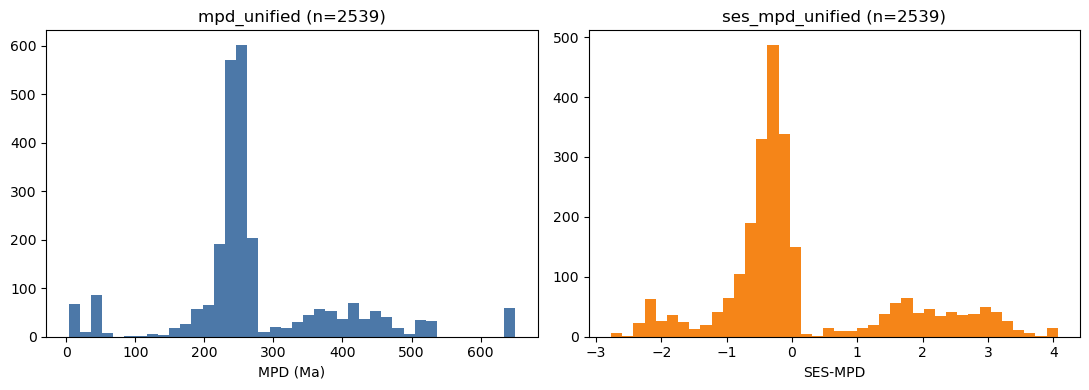

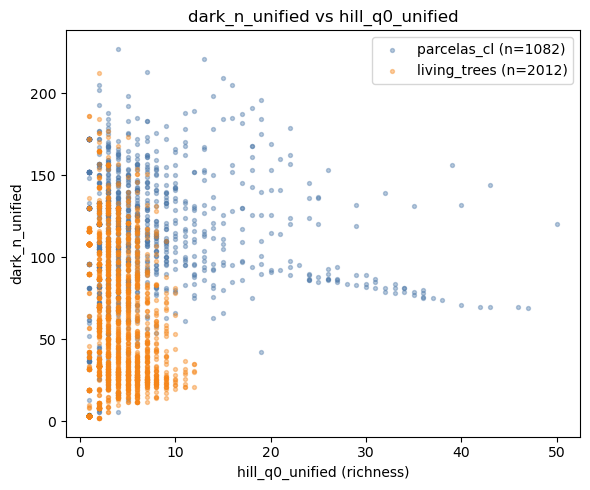

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(udf['mpd_unified'].dropna(), bins=40, color=BLUE)
ax[0].set(title='mpd_unified (n=%d)' % udf['mpd_unified'].notna().sum(), xlabel='MPD (Ma)')
ax[1].hist(udf['ses_mpd_unified'].dropna(), bins=40, color=ORANGE)
ax[1].set(title='ses_mpd_unified (n=%d)' % udf['ses_mpd_unified'].notna().sum(),
         xlabel='SES-MPD')
fig.tight_layout()

both = udf.dropna(subset=['dark_n_unified', 'hill_q0_unified'])
print(f"plots with both dark_n_unified and hill_q0_unified: {len(both)}")
print(f"corr(dark_n_unified, hill_q0_unified) = "
      f"{both['dark_n_unified'].corr(both['hill_q0_unified']):.3f} (near-orthogonal)")

fig, ax = plt.subplots(figsize=(6, 5))
for src, color in [('parcelas_cl', BLUE), ('living_trees', ORANGE)]:
    sub = both[both['source'] == src]
    ax.scatter(sub['hill_q0_unified'], sub['dark_n_unified'], s=8, alpha=0.4,
              color=color, label=f'{src} (n={len(sub)})')
ax.set(title='dark_n_unified vs hill_q0_unified', xlabel='hill_q0_unified (richness)',
      ylabel='dark_n_unified')
ax.legend()
fig.tight_layout()

### 4a. Alpha — coverage-standardized (`iNEXT.3D`, `nboot=1`, Pérez-Giraldo et al. 2025)

`scripts/63_pd_inext_coverage.R` / `scripts/64_td_inext_coverage.R` —
`iNEXT.3D::estimate3D(datatype="abundance", base="coverage", level=NULL, nboot=1)`,
the exact call and `nboot` Pérez-Giraldo use, `q=c(0,1,2)`, on the true-count matrix.
`estimate3D` hard-requires ≥5 observed species per plot — PD needs species that are
also tree tips, so it drops further (888 plots) than TD (no tree needed, 895 of the
same 2,499). Both looped plot-by-plot with `try/catch` (the package errors on a mixed
batch with any <5-species member).

**PD's near-zero correlation with `pd_faith_unified` is not a general property of
coverage-standardization** — the TD control (same method, same gate, no tree)
correlates 0.92 with `hill_q0_unified`, essentially clean. The PD-specific noise most
likely comes from pruning each plot to a very small per-plot subtree (median richness
drops to 3-5 species once restricted to tree tips) combined with branch-length
weighting, not from `base="coverage"`/`nboot=1` themselves — open question.

PD: n=888, Spearman(pd_inext_q0, pd_faith_unified) = 0.070
PD: Spearman(q0,q1) = 0.532   Spearman(q1,q2) = 0.966
TD control: n=895, Spearman(td_inext_q0, hill_q0_unified) = 0.917


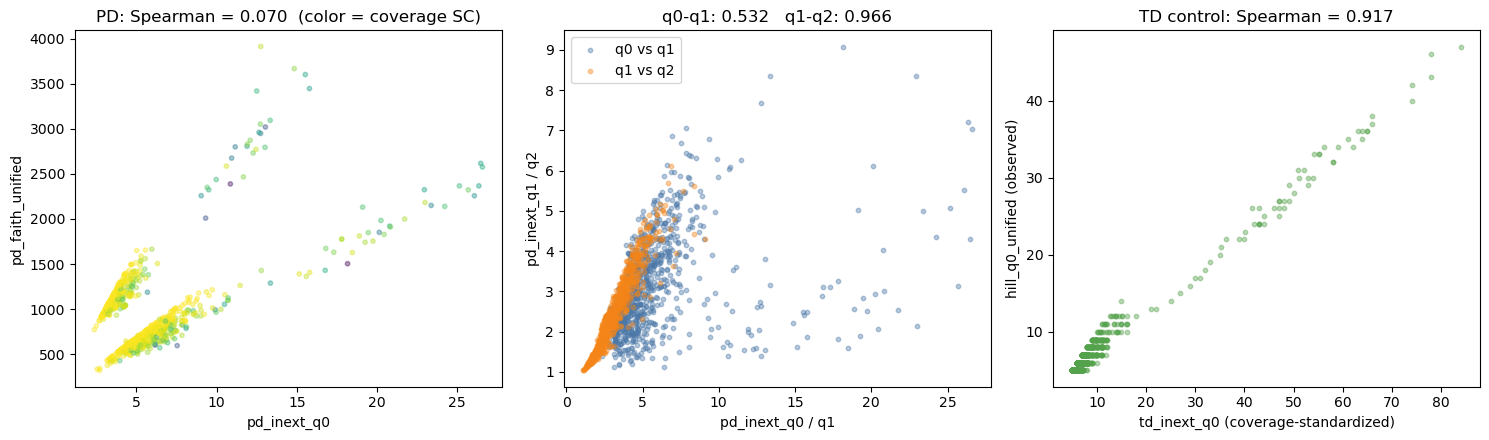

In [7]:
pd_pg = pd.read_parquet(DERIVED / 'pd_inext_coverage.parquet')
td_pg = pd.read_parquet(DERIVED / 'td_inext_coverage.parquet')
cmp_pd = pd_pg.merge(phylo[['PlotObservationID', 'pd_faith_unified']], on='PlotObservationID', how='left')
cmp_td = td_pg.merge(unified_resp[['PlotObservationID', 'hill_q0_unified']], on='PlotObservationID', how='left')

rho_pd = cmp_pd['pd_inext_q0'].corr(cmp_pd['pd_faith_unified'], method='spearman')
rho_q01 = cmp_pd['pd_inext_q0'].corr(cmp_pd['pd_inext_q1'], method='spearman')
rho_q12 = cmp_pd['pd_inext_q1'].corr(cmp_pd['pd_inext_q2'], method='spearman')
rho_td = cmp_td['td_inext_q0'].corr(cmp_td['hill_q0_unified'], method='spearman')

print(f"PD: n={len(cmp_pd)}, Spearman(pd_inext_q0, pd_faith_unified) = {rho_pd:.3f}")
print(f"PD: Spearman(q0,q1) = {rho_q01:.3f}   Spearman(q1,q2) = {rho_q12:.3f}")
print(f"TD control: n={len(cmp_td)}, Spearman(td_inext_q0, hill_q0_unified) = {rho_td:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(cmp_pd['pd_inext_q0'], cmp_pd['pd_faith_unified'], s=10, alpha=0.4,
                c=cmp_pd['sc_pd_inext'], cmap='viridis')
axes[0].set(xlabel='pd_inext_q0', ylabel='pd_faith_unified',
           title=f'PD: Spearman = {rho_pd:.3f}  (color = coverage SC)')
axes[1].scatter(cmp_pd['pd_inext_q0'], cmp_pd['pd_inext_q1'], s=10, alpha=0.4, color=BLUE, label='q0 vs q1')
axes[1].scatter(cmp_pd['pd_inext_q1'], cmp_pd['pd_inext_q2'], s=10, alpha=0.4, color=ORANGE, label='q1 vs q2')
axes[1].set(xlabel='pd_inext_q0 / q1', ylabel='pd_inext_q1 / q2',
           title=f'q0-q1: {rho_q01:.3f}   q1-q2: {rho_q12:.3f}')
axes[1].legend()
axes[2].scatter(cmp_td['td_inext_q0'], cmp_td['hill_q0_unified'], s=10, alpha=0.4, color=GREEN)
axes[2].set(xlabel='td_inext_q0 (coverage-standardized)', ylabel='hill_q0_unified (observed)',
           title=f'TD control: Spearman = {rho_td:.3f}')
fig.tight_layout()

## 5. Hill curves (q=0,1,2), taxonomic and phylogenetic — real abundance, analytical

`scripts/66_hill_curve_inext_abundance.R` — analytical rarefaction/extrapolation
(interpolation + extrapolation to 2× sample size, solid→dashed line), on real
individual counts (`occurrences_unified_counts.parquet`, 2,499 plots), **all pooled
into one assemblage** (97,063 individuals taxonomic / 96,221 restricted to the
610-tip tree for the phylogenetic panel) — x-axis is number of **individuals**
sampled from that pool, not number of plots.

- **Taxonomic**: `iNEXT::iNEXT(x, q, datatype="abundance")` — the exact function call
  Pérez-Giraldo et al. 2025 (Ecography) use. One difference from their script: they
  split into 5 fixed "Fractal" groups and plot one curve per group; we have no such
  grouping, so this is every true-count plot pooled into a single curve, not five.
- **Phylogenetic**: no equivalent in Pérez-Giraldo's own script (theirs has only the
  coverage-standardized PD *point*, `estimate3D`, already matched in §4a) — this
  extends the same analytical mechanism to PD ourselves, via
  `iNEXT.3D::iNEXT3D(diversity="PD", datatype="abundance", PDtree=...)`.
  `Type="meanPD"` (PD divided by the reference tree depth) comes from the function
  directly here, no manual normalization needed.

**Replaces** the empirical-resampling version of this curve (previously
`scripts/65_unified_hill_curve_counts.R`, growing-pool-of-plots x-axis, no
interpolation/extrapolation distinction) — this analytical version is preferred: it
has the standard rarefaction/extrapolation shape and directly extends
Pérez-Giraldo's own mechanism to phylogenetic diversity.

`nboot=1` (Pérez-Giraldo's convention, used throughout this session) breaks
`iNEXT3D`'s PD curve engine internally (`if (ans==Inf)` over an unguarded `NA` — a
real package bug in the *curve* code path, confirmed by tracing the error, distinct
from `estimate3D`'s single-point code path which tolerates `nboot=1` fine, §4a).
`nboot=0` used instead for the phylogenetic panel — same effect as `nboot=1` would
have (no confidence band, `SC`/`CI` come back `NA`), without the error. The
taxonomic panel (classic `iNEXT`, not `iNEXT.3D`) has no such issue and keeps its
default `nboot=50` — a real confidence band.

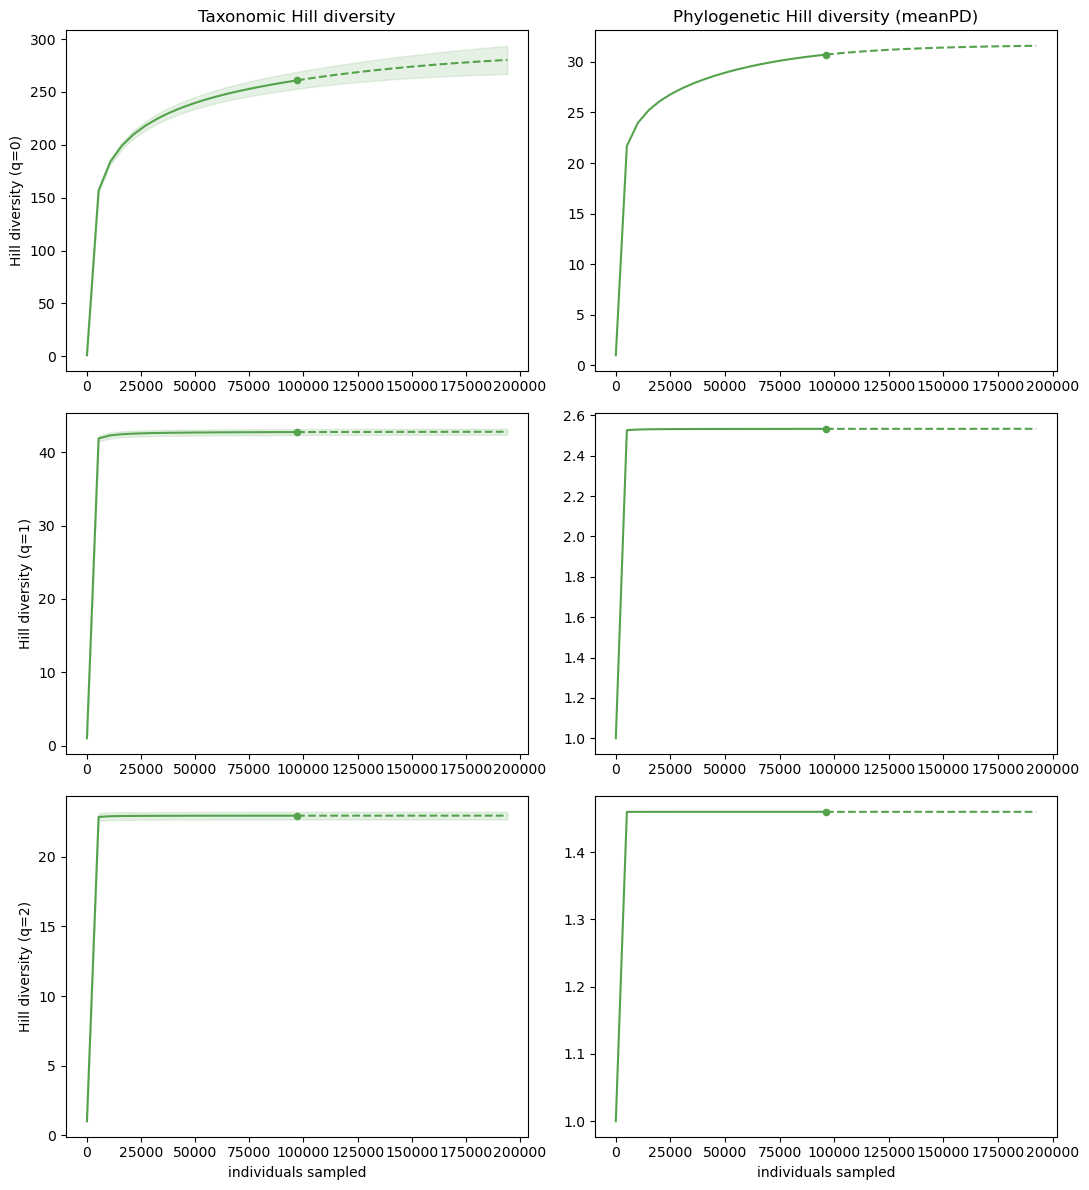

In [8]:
ic = pd.read_csv(DERIVED / 'unified_hill_curve_inext_abundance.csv')

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
metrics = ['taxonomic', 'phylogenetic']
titles = {'taxonomic': 'Taxonomic Hill diversity', 'phylogenetic': 'Phylogenetic Hill diversity (meanPD)'}
for i, q in enumerate([0, 1, 2]):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        z = ic[(ic['q'] == q) & (ic['metric'] == metric)].sort_values('n_individuals')
        obs = z[z['method'] == 'Observed']
        interp = z[z['method'].isin(['Rarefaction', 'Observed'])]
        extrap = z[z['method'].isin(['Observed', 'Extrapolation'])]
        ax.plot(interp['n_individuals'], interp['value'], '-', color=GREEN, lw=1.5)
        ax.plot(extrap['n_individuals'], extrap['value'], '--', color=GREEN, lw=1.5)
        ax.fill_between(z['n_individuals'], z['lo'], z['hi'], color=GREEN, alpha=0.15)
        ax.scatter(obs['n_individuals'], obs['value'], color=GREEN, s=20, zorder=5)
        if i == 0:
            ax.set_title(titles[metric])
        if j == 0:
            ax.set_ylabel(f'Hill diversity (q={q})')
        if i == 2:
            ax.set_xlabel('individuals sampled')
fig.tight_layout()

## 6. Beta diversity curve — Hill partition (alpha/beta/gamma, q=0,1,2)

`scripts/59_unified_beta_freq_curve.R` — `hillR::hill_taxa_parti` (Chao, Chiu & Jost
2014 multiplicative partition, β = γ/α), same empirical resampling design as §5, but
on the **broader relativized-proportion pool** (every continuous-stratum Parcelas-CL
plot + Living Trees complete = 3,273 plots × 649 species) rather than the true-count
subset — this curve intentionally maximizes pool size over currency purity, since it
is diagnostic (pool-level, not a per-plot target), not a Pérez-Giraldo cross-check.

at n=3273 (full pool):
 q  alpha_mean  beta_mean  gamma_mean
 1    2.343705  23.455768   54.973394
 0    5.054995 128.387851  649.000000
 2    1.752782  16.808055   29.460861


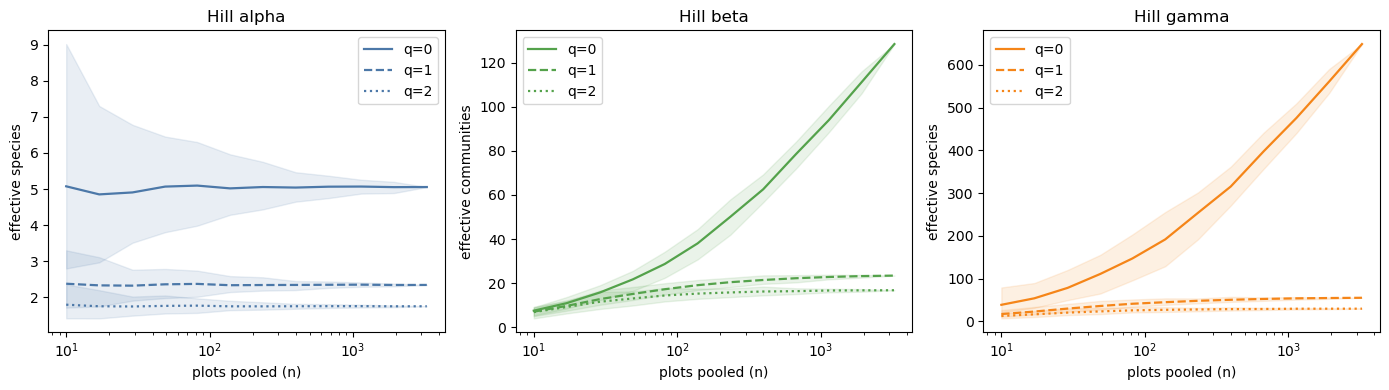

In [9]:
bc = pd.read_csv(DERIVED / 'unified_beta_freq_curve.csv').sort_values('n')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, comp, color in zip(axes, ['alpha', 'beta', 'gamma'], [BLUE, GREEN, ORANGE]):
    for q, ls in zip([0, 1, 2], ['-', '--', ':']):
        z = bc[bc['q'] == q]
        ax.plot(z['n'], z[f'{comp}_mean'], ls, color=color, lw=1.6, label=f'q={q}')
        ax.fill_between(z['n'], z[f'{comp}_lo'], z[f'{comp}_hi'], color=color, alpha=0.12)
    ax.set(title=f'Hill {comp}', xlabel='plots pooled (n)',
          ylabel='effective species' if comp != 'beta' else 'effective communities')
    ax.set_xscale('log')
    ax.legend()
fig.tight_layout()

print('at n=%d (full pool):' % bc['n'].max())
print(bc[bc['n'] == bc['n'].max()][['q', 'alpha_mean', 'beta_mean', 'gamma_mean']]
     .to_string(index=False))

## 7. Dark diversity — empirical stability curve

`scripts/57_dark_diversity_curve.R`. Dark diversity has no established
rarefaction/extrapolation theory — exploratory, not a validated prediction like §5:
how much does `DarkDiv::DarkDiv` (Hypergeometric, 0.9 threshold) **move** depending on
the size of the co-occurrence pool it is fit on. Quantifies, for the *full*
Parcelas-CL + Living Trees pool, why §4's `dark_n_unified` uses the full pool rather
than just the 3,102-plot modelling subset.

relative band width (hi-lo)/mean, smallest -> largest pool: 72.3% -> 0.0%


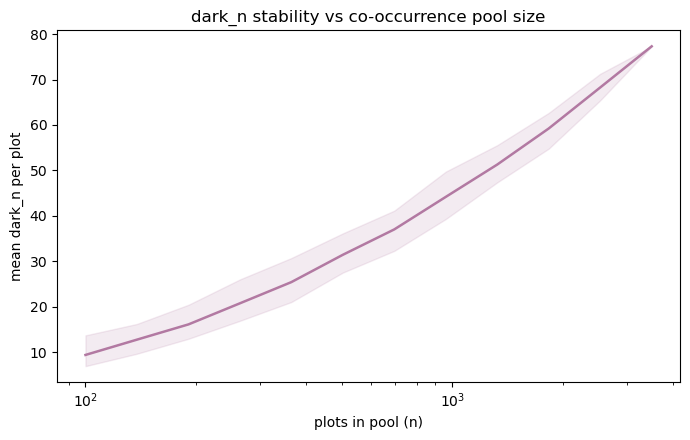

In [10]:
dc = pd.read_csv(DERIVED / 'dark_diversity_curve.csv').sort_values('n')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dc['n'], dc['dark_n_mean'], '-', color=PURPLE, lw=1.8)
ax.fill_between(dc['n'], dc['dark_n_mean_lo'], dc['dark_n_mean_hi'], color=PURPLE, alpha=0.15)
ax.set(title='dark_n stability vs co-occurrence pool size', xlabel='plots in pool (n)',
      ylabel='mean dark_n per plot')
ax.set_xscale('log')
fig.tight_layout()

rel_width = (dc['dark_n_mean_hi'] - dc['dark_n_mean_lo']) / dc['dark_n_mean']
print('relative band width (hi-lo)/mean, smallest -> largest pool: '
     f"{rel_width.iloc[0]:.1%} -> {rel_width.iloc[-1]:.1%}")

## 8. Can this be estimated for every plot? — implication for the modelling database

No, not with coverage-standardization: the ≥5-species floor is a structural property
of Chao1-type estimators, not an implementation gap — 61-65% of plots fall under it
in every true-count currency checked this session. No `level`/`nboot` setting removes
that floor.

For a **general modelling database that needs every plot**, §3-§4's full-pool facets
remain the right target set:

| facet | n plots | method |
|---|---|---|
| `hill_q0_unified` | 3,102 | observed richness, no gate |
| `lcbd_pa_unified` | 3,094 | Jaccard, presence/absence |
| `lcbd_freq_unified` | 3,040 | Hellinger, row-relativized |
| `pd_faith_unified` | ~3,102 | observed branch length, no gate |
| `dark_n_unified` | 3,102 | full co-occurrence pool |

§3a/§4a's Pérez-Giraldo-style facets (`lcbd_count_sorensen`, `pd_inext_q*`,
`td_inext_q*`) and §5's redone Hill curves are a **methodology cross-check on the
subset where it is statistically valid to run at all** — diagnostic, same status as
§6/§7's curves (`docs/11_next_steps.md`, decision #4), not modelling targets.